# Dimension and iteration curves

This exploratory study combines the target-dimension and iteration sweeps in one figure. For each target dimension, it compares Forest Sketch with one, two, and three iterations. Results are averaged across paired seeds, and the raw random-forest accuracy is shown as a dotted reference line.

The target dimensions are $d \in \{8, 32, 128, 512, 2048, 8192\}$, so the experiment covers both compressed and overcomplete representations.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.random_projection import DataDimensionalityWarning

notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists():
    notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))

warnings.filterwarnings(
    'ignore',
    category=DataDimensionalityWarning,
    message='The number of components is higher than the number of features.*',
)
from _hypothesis_utils import (
    classification_data,
    classification_score,
    downstream_classifier,
    forest_classifier,
    forest_sketch,
)

DIMENSIONS = [8, 32, 128, 512, 2048, 8192]
ITERATIONS = [1, 2, 3]
EXPERIMENT_SEEDS = (0, 1, 2)

Raw random forest baseline: accuracy=0.813
Total experiment wall-clock time: 83.4 seconds


,iterations,dimension,mean_accuracy,std_accuracy,mean_errors
0,1,8,0.595,0.036,178.333
1,1,32,0.697,0.074,133.333
2,1,128,0.751,0.049,109.667
3,1,512,0.792,0.062,91.667
4,1,2048,0.835,0.022,72.667
5,1,8192,0.841,0.022,70.000
6,2,8,0.587,0.033,181.667
7,2,32,0.669,0.066,145.667
8,2,128,0.728,0.039,119.667
9,2,512,0.794,0.073,90.667


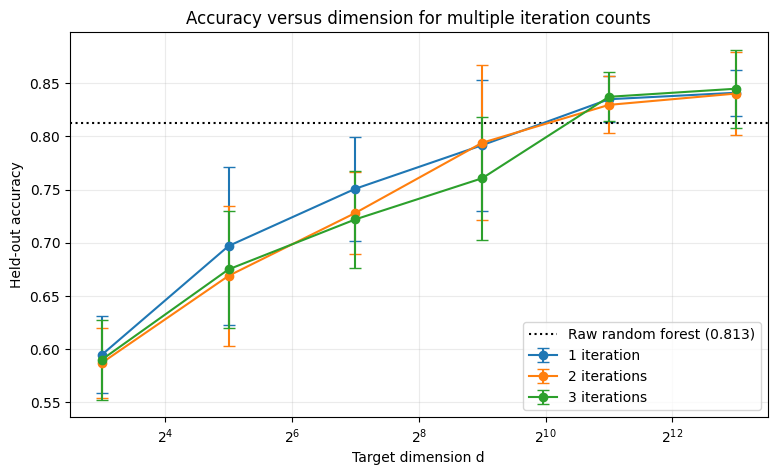

In [2]:
experiment_start = time.perf_counter()
rows = []
baseline_rows = []

for seed in EXPERIMENT_SEEDS:
    X_train, _, X_test, y_train, _, y_test = classification_data(seed)
    baseline = forest_classifier(seed)
    baseline_accuracy, baseline_errors = classification_score(
        baseline, X_train, y_train, X_test, y_test
    )
    baseline_rows.append({'seed': seed, 'accuracy': baseline_accuracy, 'errors': baseline_errors})
    for n_iterations in ITERATIONS:
        for dimension in DIMENSIONS:
            sketch = forest_sketch(seed, dimension, n_iterations)
            train_view = sketch.fit_transform(X_train, y_train)
            test_view = sketch.transform(X_test)
            accuracy, errors = classification_score(
                downstream_classifier(seed), train_view, y_train, test_view, y_test
            )
            rows.append({
                'seed': seed,
                'iterations': n_iterations,
                'dimension': dimension,
                'accuracy': accuracy,
                'errors': errors,
            })

results = pd.DataFrame(rows)
summary = (
    results.groupby(['iterations', 'dimension'])
    .agg(mean_accuracy=('accuracy', 'mean'), std_accuracy=('accuracy', 'std'), mean_errors=('errors', 'mean'))
    .reset_index()
)
baseline_summary = pd.DataFrame(baseline_rows)
raw_accuracy = baseline_summary['accuracy'].mean()
print(f'Raw random forest baseline: accuracy={raw_accuracy:.3f}')
print(f'Total experiment wall-clock time: {time.perf_counter() - experiment_start:.1f} seconds')
display(summary.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
for n_iterations in ITERATIONS:
    curve = summary[summary['iterations'] == n_iterations]
    ax.errorbar(
        curve['dimension'],
        curve['mean_accuracy'],
        yerr=curve['std_accuracy'],
        marker='o',
        capsize=4,
        label=f'{n_iterations} iteration' + ('s' if n_iterations != 1 else ''),
    )
ax.axhline(raw_accuracy, color='black', linestyle=':', linewidth=1.5, label=f'Raw random forest ({raw_accuracy:.3f})')
ax.set_xscale('log', base=2)
ax.set_xlabel('Target dimension d')
ax.set_ylabel('Held-out accuracy')
ax.set_title('Accuracy versus dimension for multiple iteration counts')
ax.grid(alpha=0.25, which='both')
ax.legend()
plt.show()

## Reading the figure

Each point is the mean held-out accuracy across the paired seeds, and each error bar is one standard deviation. The horizontal dotted line is the mean raw random-forest baseline. This notebook is exploratory: it shows how dimension and iteration interact, but it does not replace the dedicated hypothesis notebooks or cross-validated model selection.